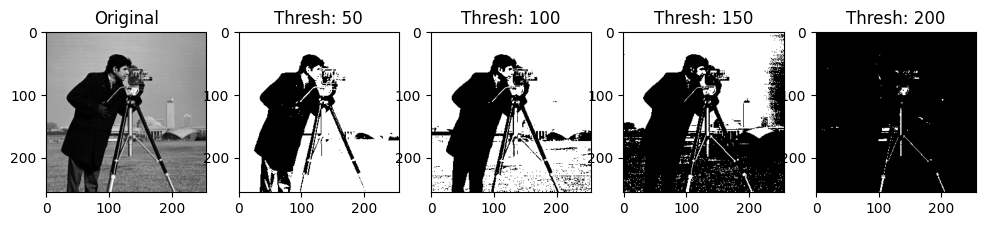

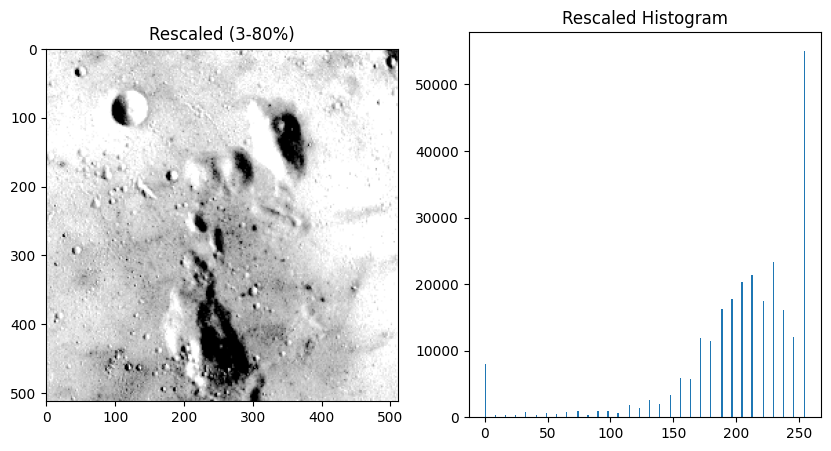

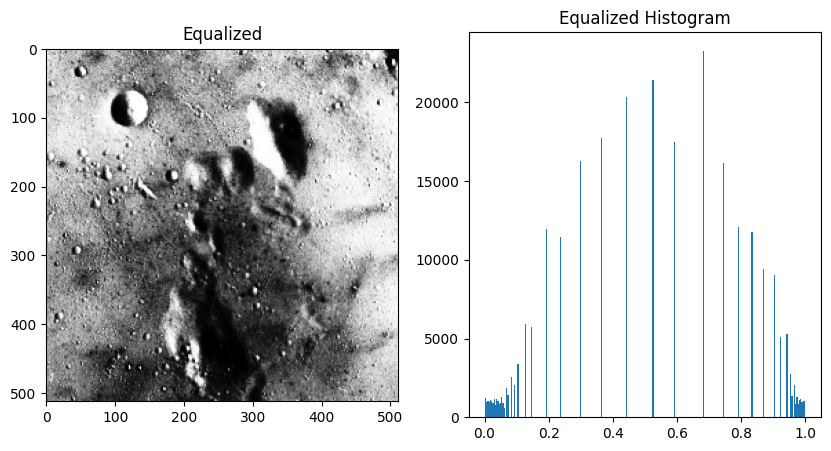

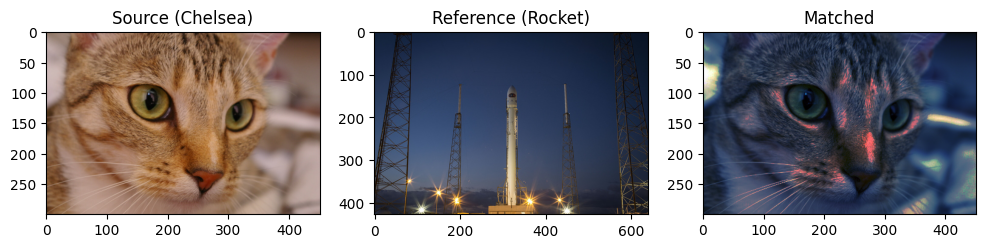

True

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

# Load images
img_gray = cv2.imread('images/cameraman.tif', 0)
img_moon = data.moon()

# --- Task 1: Thresholding ---
# Applying multiple threshold values
threshold_values = [50, 100, 150, 200]

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1); plt.imshow(img_gray, cmap='gray'); plt.title('Original')

for i, val in enumerate(threshold_values):
    # Apply binary thresholding
    ret, thresh = cv2.threshold(img_gray, val, 255, cv2.THRESH_BINARY)
    plt.subplot(1, 5, i + 2)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Thresh: {val}')
plt.show()

# --- Task 2: Assessment Task 1 (Contrast Stretching) ---
# Rescale between 3rd and 80th percentiles
p3, p80 = np.percentile(img_moon, (3, 80))
img_rescale = exposure.rescale_intensity(img_moon, in_range=(p3, p80))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_rescale, cmap='gray'); plt.title('Rescaled (3-80%)')
plt.subplot(1, 2, 2); plt.hist(img_rescale.flat, bins=256); plt.title('Rescaled Histogram')
plt.show()

# --- Task 2: Assessment Task 2 (Histogram Equalization) ---
# Flattening the histogram
img_eq = exposure.equalize_hist(img_moon)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_eq, cmap='gray'); plt.title('Equalized')
plt.subplot(1, 2, 2); plt.hist(img_eq.flat, bins=256); plt.title('Equalized Histogram')
plt.show()

# --- Task 2: Assessment Task 3 (Histogram Matching) ---
# Match Chelsea (source) to Rocket (reference)
source = data.chelsea()
reference = data.rocket()
matched = exposure.match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(source); plt.title('Source (Chelsea)')
plt.subplot(1, 3, 2); plt.imshow(reference); plt.title('Reference (Rocket)')
plt.subplot(1, 3, 3); plt.imshow(matched); plt.title('Matched')
plt.show()

# Save output
cv2.imwrite('images/lab4_output.jpg', (img_eq * 255).astype(np.uint8))